<a href="https://colab.research.google.com/github/sivaroshan2007/Data-Analysis-Projects/blob/main/Task_2_(Synent_tech).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install -q kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter


file_path = "Mall_Customers.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "abdallahwagih/mall-customers-segmentation",
    file_path
)

print("Dataset Shape:", df.shape)
df.head()

/tmp/ipykernel_646/2891114911.py:11: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'mall-customers-segmentation' dataset.
Dataset Shape: (200, 5)


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


FEATURE SELECTION & CLEANING

In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [5]:
# Droping 'CustomerID' as it contains no predictive or clustering value
df_cleaned = df.drop(columns=['CustomerID'])

In [7]:
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [15]:
if df_cleaned.isnull().sum().sum() > 0:
    df_cleaned = df_cleaned.dropna()

In [16]:
for i in df.columns:
    if df[i].isna().any():
        print(i)

CATEGORICAL ENCODING

In [23]:
df_processed = pd.get_dummies(df_cleaned, columns=['Genre'], drop_first=True)

FEATURE SCALING

In [24]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_processed)
X_preprocessed = pd.DataFrame(scaled_features, columns=df_processed.columns)

VERIFY PREPROCESSED DATA

In [25]:
print("Shape of preprocessed data:", X_preprocessed.shape)
print("\nFirst 5 rows of fully preprocessed data (Ready for K-Means):")
X_preprocessed.head()

Shape of preprocessed data: (200, 4)

First 5 rows of fully preprocessed data (Ready for K-Means):


,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
0,-1.424569,-1.738999,-0.434801,1.128152
1,-1.281035,-1.738999,1.195704,1.128152
2,-1.352802,-1.700830,-1.715913,-0.886405
3,-1.137502,-1.700830,1.040418,-0.886405
4,-0.563369,-1.662660,-0.395980,-0.886405


Over-scaling Binary Data Detected

In [27]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Clean up and handle categorical variables first
df_cleaned = df.drop(columns=['CustomerID'])
df_processed = pd.get_dummies(df_cleaned, columns=['Genre'], drop_first=True)


# Spliting into features to scale vs. features to keep as binary
continuous_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
binary_cols = [col for col in df_processed.columns if col not in continuous_cols]

scaler = StandardScaler()
scaled_continuous = scaler.fit_transform(df_processed[continuous_cols])

#  Rebuilding the clean, perfectly formatted DataFrame
X_preprocessed = pd.DataFrame(scaled_continuous, columns=continuous_cols)

# Re-attach the unscaled binary columns (0 and 1)
for col in binary_cols:
    X_preprocessed[col] = df_processed[col].reset_index(drop=True).astype(int)

# =====================================================================
# VERIFY THE CORRECTED OUTPUT
# =====================================================================
print("Perfected Data (Ready for K-Means):")
X_preprocessed.head()

Perfected Data (Ready for K-Means):


,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
0,-1.424569,-1.738999,-0.434801,1
1,-1.281035,-1.738999,1.195704,1
2,-1.352802,-1.700830,-1.715913,0
3,-1.137502,-1.700830,1.040418,0
4,-0.563369,-1.662660,-0.395980,0


Visualtising the clusters

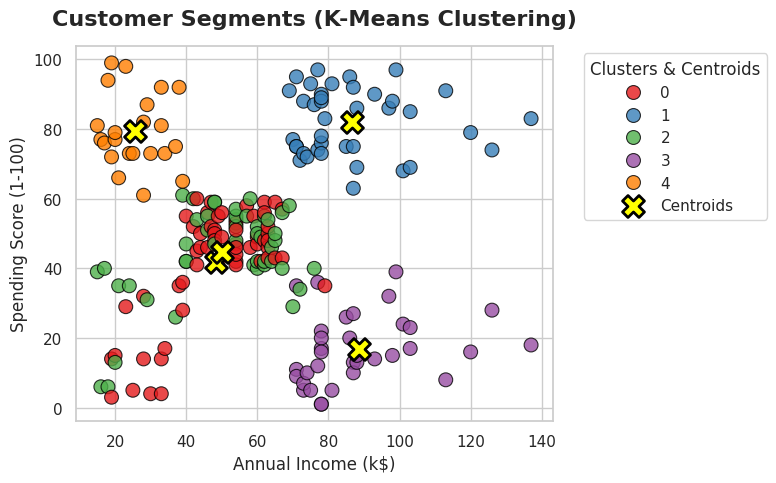

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans

#Training the K-Means model on your preprocessed data
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
cluster_labels = kmeans.fit_predict(X_preprocessed)


df['Cluster'] = cluster_labels

# =====================================================================
# VISUALIZATION PART
# =====================================================================
sns.set_theme(style='whitegrid')
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=df,
    palette='Set1',
    s=100,
    alpha=0.8,
    edgecolor='black'
)

# Extracting and un-scale the centroids to map them back to the original scale
centroids_scaled = kmeans.cluster_centers_
centroids_continuous = scaler.inverse_transform(centroids_scaled[:, :3])

# Ploting the centroids as large yellow X marks
plt.scatter(
    centroids_continuous[:, 1], # Un-scaled Annual Income
    centroids_continuous[:, 2], # Un-scaled Spending Score
    s=250,
    c='yellow',
    marker='X',
    edgecolors='black',
    linewidths=2,
    label='Centroids'
)

# Polishing the chart layout
plt.title('Customer Segments (K-Means Clustering)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend(title='Clusters & Centroids', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()